In [7]:
import pandas as pd
from Evaluation.OntoMapping_benchmark.src.compute_scores import parse_to_list_of_strings
from RAG_mapper.src.llm_model import SchemaNode

/home/bbf1146/miniconda3/envs/lu_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
llm_models = ['gemma4:latest', 'gpt-oss:120b', 'qwen3.5:4b', 'gpt-oss:20b']
with open('results/OntoMapping_benchmark/llms_benchmarking/supervisor_llm/computational_time_selector.txt', 'r') as file:
    time_supervisor = file.read()

time_supervisor

'gemma4:latest: 00:20:44 \ngpt-oss:120b: 01:10:13 \nqwen3.5:4b: 01:31:14 \ngpt-oss:20b: 00:08:39 \n'

In [14]:
def read_selector_file(x: str, source_onto: str, target_onto:str) -> pd.DataFrame:
    df = pd.read_csv(f'results/OntoMapping_benchmark/llms_benchmarking/selector_output_{x}_25_{source_onto}_{target_onto}.csv')
    df[f'{target_onto}_ids'] = df[f'{target_onto}_ids'].apply(lambda x: parse_to_list_of_strings(x))
    df['se_codes'] = df['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
    df['AI_code'] = df['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)
    return df

def read_supervisor_file(x: str, source_onto: str, target_onto:str) -> pd.DataFrame:
    df = pd.read_csv(f'results/OntoMapping_benchmark/llms_benchmarking/supervisor_llm/supervisor_output_{x}_25_{source_onto}_{target_onto}.csv')
    df[f'{target_onto}_ids'] = df[f'{target_onto}_ids'].apply(lambda x: parse_to_list_of_strings(x))
    df['se_codes'] = df['se_codes'].apply(lambda x: parse_to_list_of_strings(x))
    df['AI_code'] = df['AI_code'].apply(lambda x: str(int(x)) if isinstance(x, float) and not pd.isna(x) else str(x) if not pd.isna(x) else None)
    return df





In [36]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams['figure.facecolor'] = 'white' # Ensure entire figure background is pure white
plt.rcParams['axes.edgecolor'] = 'black'  # Sharpen axis lines for contrast

def parse_to_list(x):
    if pd.isna(x): return []
    try:
        # Handles both string-represented lists and actual lists
        return ast.literal_eval(x) if isinstance(x, str) else x
    except:
        return []

def run_evaluation(df_sel, eval_dict):
    # 1. Load Selector Data
    df_sel['LNC_ids'] = df_sel['LNC_ids']
    df_sel['se_codes'] = df_sel['se_codes']

    # Retrieval Hit@1 Logic
    df_sel['retrieval_correct'] = df_sel.apply(
        lambda r: 1 if (len(r['se_codes']) > 0 and r['se_codes'][0] in r['LNC_ids']) else 0, axis=1
    )

    # Selector Accuracy Logic
    df_sel['sel_correct'] = df_sel.apply(
        lambda r: 1 if r['AI_code'] in r['LNC_ids'] else 0, axis=1
    )

    accuracy_data = [
        {'Stage': 'Retrieval Hit@1', 'Accuracy': df_sel['retrieval_correct'].mean()},
        {'Stage': 'Selector', 'Accuracy': df_sel['sel_correct'].mean()}
    ]

    correction_results = []

    # 2. Process Supervisors
    for name, df_sup in eval_dict.items():
        # Merge on CUI to compare Selector vs Supervisor for the same query
        merged = pd.merge(df_sel[['CUI', 'LNC_ids', 'sel_correct']],
                          df_sup[['CUI', 'AI_code']], on='CUI')

        merged['sup_correct'] = merged.apply(
            lambda r: 1 if r['AI_code'] in r['LNC_ids'] else 0, axis=1
        )

        # Add to Accuracy table
        accuracy_data.append({'Stage': f'Sup: {name}', 'Accuracy': merged['sup_correct'].mean()})

        # Calculate Corrections
        fixed = len(merged[(merged['sel_correct'] == 0) & (merged['sup_correct'] == 1)])
        broken = len(merged[(merged['sel_correct'] == 1) & (merged['sup_correct'] == 0)])

        correction_results.append({'Supervisor': name, 'Fixed': fixed, 'Broken': -broken})

    # 3. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Plot A: Accuracy Comparison (Using global colorblind palette)
    acc_df = pd.DataFrame(accuracy_data)
    # Applied 'hue' and set 'palette="colorblind"' directly for safety
    sns.barplot(x='Stage', y='Accuracy', data=acc_df,
                hue='Stage', palette='colorblind', ax=ax1, legend=False)

    ax1.set_title('Pipeline Accuracy (Membership Match)')
    ax1.set_ylim(0, 1.1)
    ax1.set_ylabel('Accuracy Rate')
    # Use bold black text on annotations for readability
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height() + 0.02),
                     ha='center', fontsize=11, color='black', fontweight='bold')

    # Plot B: Supervisor Impact (Using specific, contrasting colorblind hues)
    corr_df = pd.DataFrame(correction_results).melt(id_vars='Supervisor')

    # Define an accessible mapping: High Contrast Blue and Orange
    accessible_correction_palette = {
        'Fixed': '#0072B2',  # Blue (clear winner contrast)
        'Broken': '#E69F00'  # Orange (distinct from blue, safe vs red/green)
    }

    sns.barplot(x='Supervisor', y='value', hue='variable', data=corr_df,
                ax=ax2, palette=accessible_correction_palette)

    ax2.axhline(0, color='black', linewidth=1.5)
    ax2.set_ylabel('Number of Samples')
    ax2.set_title('Supervisor Correction Impact (Fixed vs Broken)')

    # Add a legend with white background for clarity
    ax2.legend(title='Impact Type', frameon=True, facecolor='white', edgecolor='gray')

    plt.tight_layout()
    plt.savefig('results/OntoMapping_benchmark/llms_benchmarking/supervisor_llm/ontology_mapping_performance.png')
    print("Metrics calculated and plots saved as 'ontology_mapping_performance.png'")



In [22]:
eval_dict = {llm: read_supervisor_file(llm, 'NCBI', 'LNC') for llm in llm_models}
eval_dict[llm_models[0]]

,Unnamed: 0.1,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,81,C0014323,"[LP16698-0, MTHU004659, LA19278-3]",['5759'],"['Entamoeba histolytica', 'Entamoeba histolyti...",['Entamoeba histolytica'],"[LP16698-0, LA19278-3, MTHU004659, LP16698-0, ...","['Entamoeba histolytica', 'Entamoeba histolyti...",LP16698-0,Entamoeba histolytica
1,70,323,C0242906,[LP14266-8],['29176'],['Neospora caninum'],['Neospora caninum'],"[LP14266-8, LP14266-8, MTHU011493, LP422154-7,...","['Neospora caninum', 'Neospora caninum', 'Neos...",LP14266-8,Neospora caninum
2,82,482,C0319923,"[LP13999-5, LA19331-0]","['33178', '33178']","['Aspergillus terreus', 'Aspergillus terreus']","['Aspergillus terreus', 'Aspergillus terrestris']","[LP13999-5, LA19331-0, LP13999-5, LP36664-8, L...","['Aspergillus terreus', 'Aspergillus terreus',...",LP13999-5,Aspergillus terreus
3,28,181,C0033734,"[LP14843-4, MTHU071111]",['3110'],"['Prototheca', 'Prototheca']",['Prototheca'],"[MTHU071111, LP14843-4, LP14843-4, 10713-6, 10...","['Prototheca', 'Prototheca', 'Prototheca', 'Pr...",MTHU071111,Prototheca
4,63,328,C0260106,[LP427109-6],"['36651', '36651']",['Penicillium digitatum'],"['Penicillium digitatum', 'Monilia digitata']","[LP427109-6, LP427109-6, MTHU066532, LP427108-...","['Penicillium digitatum', 'Penicillium digitat...",LP427109-6,Penicillium digitatum
...,...,...,...,...,...,...,...,...,...,...,...
158,134,624,C0949895,[LP434522-1],"['186540', '186540', '186540', '186540']",['Sudan virus'],"['Sudan Ebola virus', 'Sudan virus', 'Sudan eb...","[LG32761-5, LP17696-3, LP17696-3, LP185762-4, ...","['Ebola virus', 'Ebola virus', 'Ebola virus', ...",None,NaN
159,128,681,C1024145,"[LP17624-5, LP17624-5]","['63396', '63396']","['Ustilago cynodontis', 'Ustilago cynodontis (...","['Ustilago cynodontis', 'Ustilago carbo AY cyn...","[LP17624-5, LP17624-5, MTHU024165, LP147936-1,...","['Ustilago cynodontis', 'Ustilago cynodontis (...",LP17624-5,Ustilago cynodontis
160,102,582,C0446025,[LA32432-9],"['145392', '145392', '145392', '145392', '1453...",['Bipolaris spicifera'],"['Curvularia spicifera', 'Bipolaris spicifera'...","[LA32432-9, LP17065-1]","['Bipolaris spicifera', 'Distichlis spicata']",LA32432-9,Bipolaris spicifera
161,145,700,C1047380,"[LP199461-7, LP199461-7]","['102694', '102694']","['Ulmus crassifolia', 'Cedar elm (Ulmus crassi...","['Ulmus crassifolia', 'cedar elm']","[LP199461-7, LP199461-7, LP13920-1, LP13920-1,...","['Ulmus crassifolia', 'Cedar elm (Ulmus crassi...",LP199461-7,Cedar elm (Ulmus crassifolia)


['gemma4:latest', 'gpt-oss:120b', 'qwen3.5:4b', 'gpt-oss:20b']

In [26]:
granite_selector = read_selector_file('granite4:latest', 'NCBI', 'LNC')
granite_selector.head()

,Unnamed: 0,CUI,LNC_ids,NCBI_ids,LNC_names,NCBI_names,se_codes,se_names,AI_code,AI_name
0,8,C0002331,[LP66443-0],"['11019', '11019']",['Alphavirus'],"['Alphavirus', 'Alphaviridae']","[LP66443-0, LP66443-0, LP66444-8, MTHU027941, ...","['Alphavirus', 'Alphavirus', 'Alphavirus RNA',...",LP66443-0,Alphavirus
1,70,C0012984,[LA14178-0],"['9615', '9615', '9615', '9615', '9615', '9615']",['Dog'],"['Canis familiaris', 'Canis borealis', 'Canis ...","[LP183663-6, LP14092-8, LA19198-3, LP14092-8, ...","['Canis familiaris native (nCan f) 1', 'Brucel...",LP183663-6,Canis familiaris native (nCan f)
2,82,C0014344,"[LP105046-9, LA21491-8]","['547', '547', '547']","['Enterobacter sp', 'Enterobacter species']","['Enterobacter', 'Cloaca', '""Aerobacter"" Horma...","[MTHU014226, LP28822-2, LP28822-2, LA21490-0, ...","['Aeromonas sp', 'Aeromonas sp', 'Aeromonas sp...",None,NaN
3,28,C0004663,[LP16785-5],"['817', '817', '817', '817', '817', '817', '81...",['Bacteroides fragilis'],"['Bacteroides fragilis', 'Bacteroides fragilis...","[LP16785-5, LP16785-5, MTHU014763, MTHU014763,...","['Bacteroides fragilis', 'Bacteroides fragilis...",LP16785-5,Bacteroides fragilis
4,63,C0010150,"[LP16683-2, MTHU006922, LG41614-5]","['1717', '1717', '1717', '1717', '1717', '1717...","['Corynebacterium diphtheriae', 'Corynebacteri...","['Corynebacterium diphtheriae', 'Bacillus diph...","[LP16683-2, LG41614-5, MTHU006922, LP16683-2, ...","['Corynebacterium diphtheriae', 'Corynebacteri...",LP16683-2,Corynebacterium diphtheriae


In [24]:
type(row['LNC_ids'])

list

Metrics calculated and plots saved as 'ontology_mapping_performance.png'


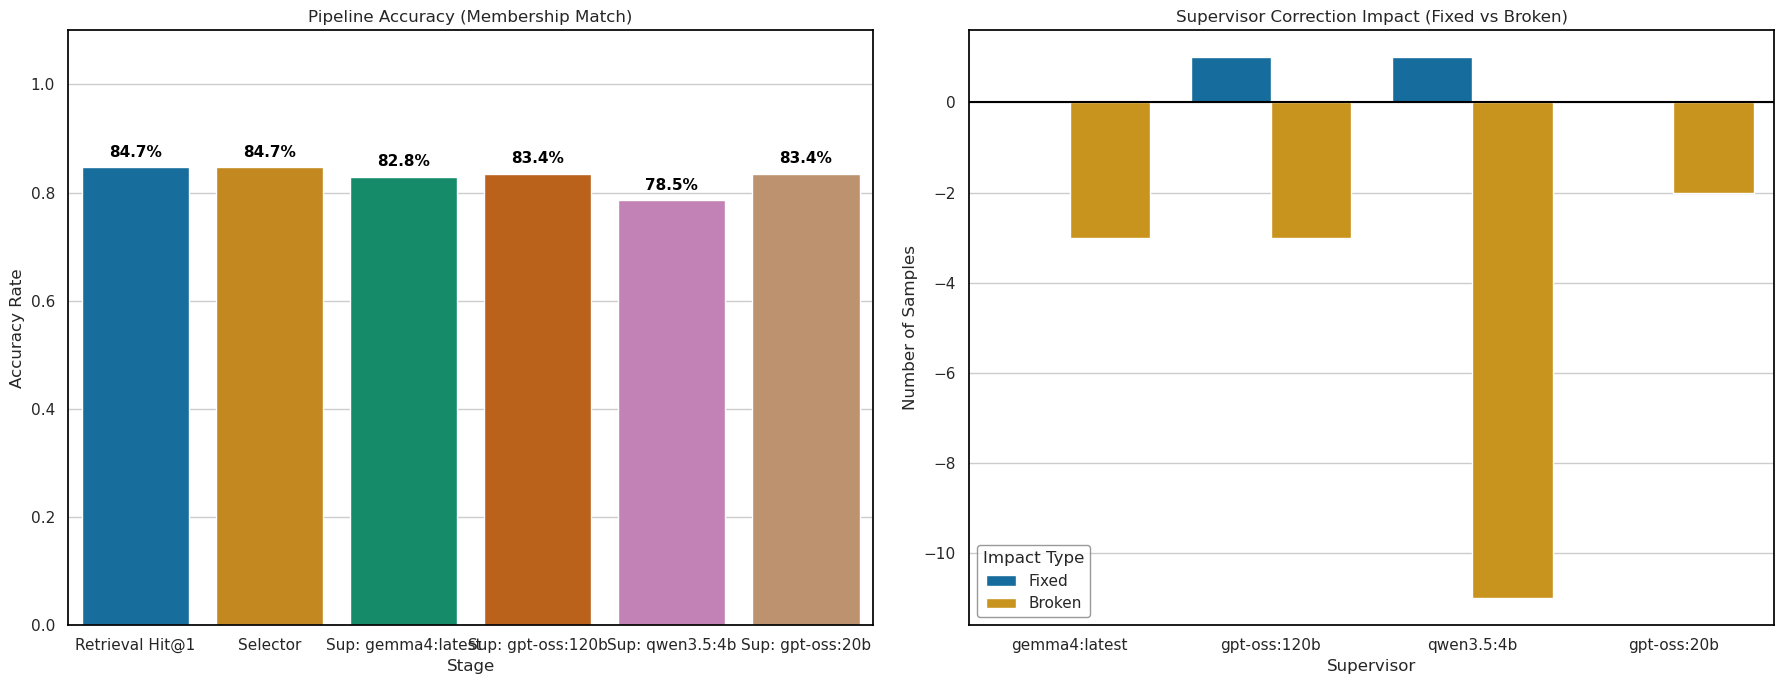

In [37]:
run_evaluation(granite_selector, eval_dict)

In [10]:
row.get('se_codes')


['LP66443-0', 'LP66443-0', 'LP66444-8', 'MTHU027941', 'LP66444-8']

In [40]:
for name, df_sup in eval_dict.items():
    print(name)


gemma4:latest
gpt-oss:120b
qwen3.5:4b
gpt-oss:20b


In [42]:
eval_dict.keys()

dict_keys(['gemma4:latest', 'gpt-oss:120b', 'qwen3.5:4b', 'gpt-oss:20b'])

In [39]:
granite_selector = granite_selector.rename(columns={'AI_code': 'AI_code_sel', 'AI_name': 'AI_name_sel'})

for name, df_sup in eval_dict.items():
    df_sup = df_sup[['CUI', 'AI_code', 'AI_name']]

    # Rename columns to identify which supervisor they belong to
    df_sup = df_sup.rename(columns={
        'AI_code': f'AI_code_{name}',
        'AI_name': f'AI_name_{name}'
    })

    df_master = pd.merge(granite_selector, df_sup, on='CUI', how='left')

df_master.columns


Index(['Unnamed: 0', 'CUI', 'LNC_ids', 'NCBI_ids', 'LNC_names', 'NCBI_names',
       'se_codes', 'se_names', 'AI_code_sel', 'AI_name_sel',
       'retrieval_correct', 'sel_correct', 'AI_code_gpt-oss:20b',
       'AI_name_gpt-oss:20b'],
      dtype='object')